In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

In [3]:
df = pd.read_csv('../dataset/train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])

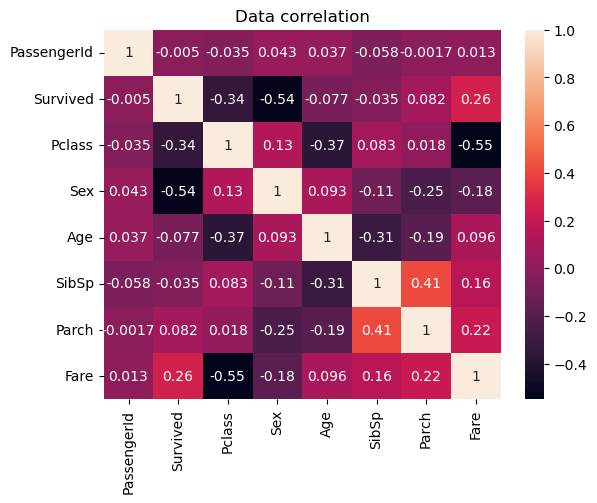

In [5]:
# Data Correlation, Interpretasi Data
df_correlation = df.corr(numeric_only=True)
sns.heatmap(df_correlation, annot=True)
plt.title('Data correlation')
plt.show()

In [7]:
df = df[['Survived', 'Sex', 'Pclass', 'Fare', 'Parch', 'Age', 'SibSp']].copy()

In [8]:
df.isnull().sum()

Survived      0
Sex           0
Pclass        0
Fare          0
Parch         0
Age         177
SibSp         0
dtype: int64

In [9]:
df['Age'] = df['Age'].fillna(df['Age'].median())

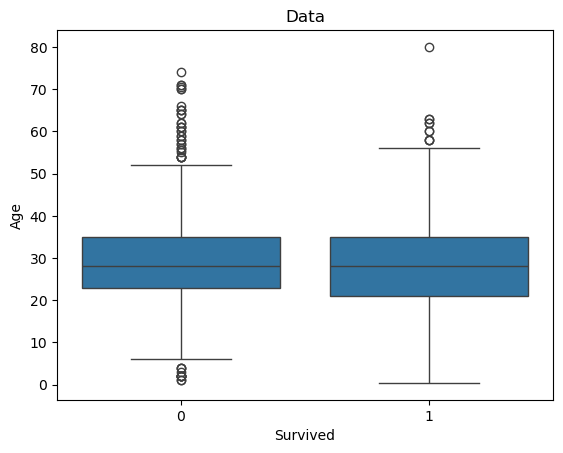

In [10]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.title('Data')
plt.show()

In [11]:
q1 = df['Age'].quantile(0.25)
q3 = df['Age'].quantile(0.75)

iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

df['Age'] = df['Age'].clip(lower=lower_limit, upper=upper_limit)

In [12]:
# splitting 
x = df.drop(['Survived'], axis=1)
y = df['Survived']

x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=42, test_size=0.2)

In [13]:
# Model Logistic Regression

# Pipeline (Modeling and Scaling)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression())
])

# Hyperparameter Tuning dan Optimasi Model
param_grid = {
    'logreg__C': [0.1, 1, 10, 100],
    'logreg__solver': ['lbfgs']
}

# Training
grid = GridSearchCV(pipeline, param_grid, cv=5)
grid.fit(x_train, y_train)

model = grid.best_estimator_

# Evalusi Model
akurasi_train = model.score(x_train, y_train)
akurasi_test = model.score(x_test, y_test)

In [ ]:
# Perbandingan Model Random Forest Classifier

# Pipeline (Modeling and Scaling)
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(random_state=42))
])

# Hyperparameter Tuning dan Optimasi Model
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300, 500],
    'rf__max_depth': [1, 2, 3, 4, 5]
}

# Training
grid_rf = GridSearchCV(pipeline_rf, param_grid_rf, cv=5)
grid_rf.fit(x_train, y_train)

model_rf = grid_rf.best_estimator_

akurasi_train_tf = model_rf.score(x_train, y_train)
akurasi_test_tf = model_rf.score(x_test, y_test)

In [ ]:
# Validasi Performa, Analisis Hasil Prediksi
pred_logreg = model.predict(x_test) 
pred_rf = model_rf.predict(x_test)

print(classification_report(y_test, pred_logreg))
print(classification_report(y_test, pred_rf))

print(grid.best_params_)
print(akurasi_train)
print(akurasi_test)

print('\n')

print(grid_rf.best_params_)
print(akurasi_train_rf)
print(akurasi_test_rf)

In [ ]:
# Metrics Evaluasi
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, pred_logreg, display_labels=['Tewas', 'Selamat'], ax=ax[0], cmap='Reds')
ax[0].set_title('Analisis LogReg')

# Random Forest
ConfusionMatrixDisplay.from_predictions(y_test, pred_rf, display_labels=['Tewas', 'Selamat'], ax=ax[1], cmap='Blues')
ax[1].set_title('Analisis RF')

plt.show()

In [ ]:
importances_log = abs(model.named_steps['logreg'].coef_[0])
importances_rf = model_rf.named_steps['rf'].feature_importances_

df_penting = pd.DataFrame({
    'Fitur': x.columns,
    'LogReg_Importance': importances_log,
    'RF_Importance': importances_rf
}).sort_values(by='RF_Importance', ascending=False)

print(df_penting)